Missing Values:
 Student_ID        0
Name              0
Gender            0
Department        0
Year              0
Maths             0
Science           0
English           0
Attendance (%)    0
Internal Marks    0
dtype: int64

--- Descriptive Statistics ---
       Student_ID       Maths     Science     English  Attendance (%)  \
count  250.000000  250.000000  250.000000  250.000000      250.000000   
mean   125.500000   69.608000   68.468000   70.200000       75.248000   
std     72.312977   17.921917   17.515139   16.749513       14.392745   
min      1.000000   40.000000   40.000000   40.000000       50.000000   
25%     63.250000   54.250000   53.000000   57.000000       63.250000   
50%    125.500000   69.000000   67.500000   70.500000       74.000000   
75%    187.750000   86.750000   84.000000   85.750000       87.000000   
max    250.000000   99.000000   99.000000   99.000000      100.000000   

       Internal Marks       Total     Average  
count      250.000000  250.00000

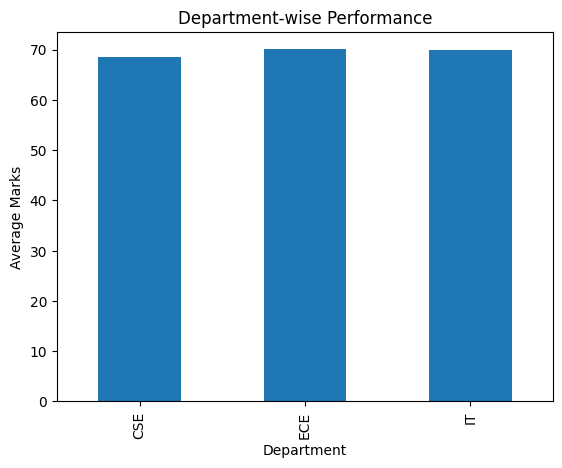

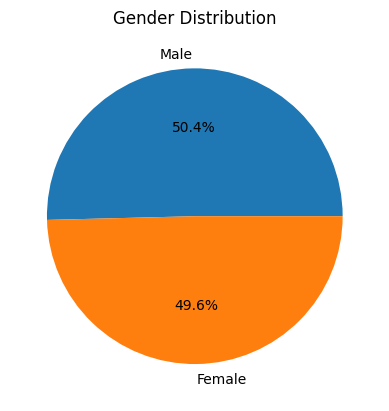

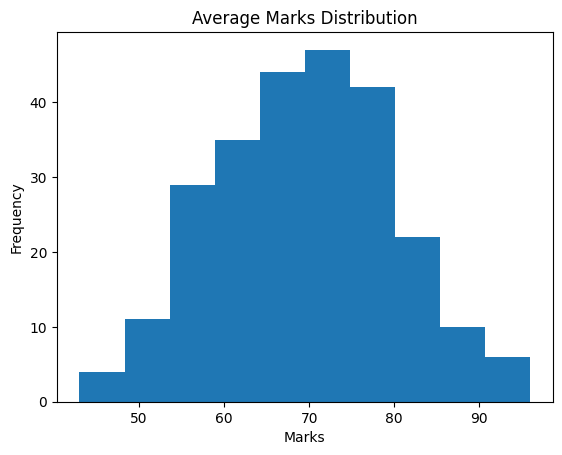

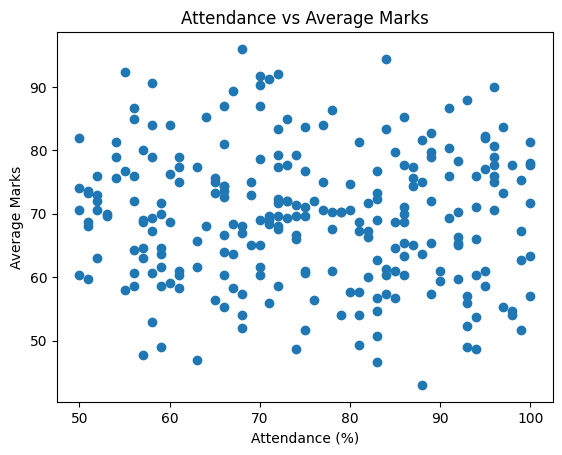


Dataset saved as student_performance.csv


In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
np.random.seed(42)
n = 250

names = [f"Student_{i}" for i in range(1, n+1)]
genders = np.random.choice(['Male', 'Female'], n)
departments = np.random.choice(['CSE', 'IT', 'ECE'], n)
years = np.random.choice(['1st', '2nd', '3rd'], n)

data = {
    "Student_ID": range(1, n+1),
    "Name": names,
    "Gender": genders,
    "Department": departments,
    "Year": years,
    "Maths": np.random.randint(40, 100, n),
    "Science": np.random.randint(40, 100, n),
    "English": np.random.randint(40, 100, n),
    "Attendance (%)": np.random.randint(50, 101, n),
    "Internal Marks": np.random.randint(0, 26, n)
}
df = pd.DataFrame(data)
print("Missing Values:\n", df.isnull().sum())
df["Total"] = df["Maths"] + df["Science"] + df["English"]
df["Average"] = df["Total"] / 3

def grade(avg):
    if avg >= 85:
        return "A"
    elif avg >= 70:
        return "B"
    elif avg >= 50:
        return "C"
    else:
        return "Fail"

df["Grade"] = df["Average"].apply(grade)

print("\n--- Descriptive Statistics ---")
print(df.describe())

top_students = df.sort_values(by="Total", ascending=False).head(5)
low_students = df[df["Grade"] == "Fail"]

print("\nTop 5 Students:\n", top_students[["Name", "Total"]])
print("\nFail Students:\n", low_students[["Name", "Average"]])

print("\nDepartment-wise Average Marks:")
print(df.groupby("Department")["Average"].mean())

print("\nGender-wise Average Marks:")
print(df.groupby("Gender")["Average"].mean())

print("\nYear-wise Average Marks:")
print(df.groupby("Year")["Average"].mean())
print("\nCorrelation:\n", df[["Attendance (%)", "Internal Marks", "Average"]].corr())

df.groupby("Department")["Average"].mean().plot(kind='bar')
plt.title("Department-wise Performance")
plt.xlabel("Department")
plt.ylabel("Average Marks")
plt.show()

df["Gender"].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

plt.hist(df["Average"])
plt.title("Average Marks Distribution")
plt.xlabel("Marks")
plt.ylabel("Frequency")
plt.show()

plt.scatter(df["Attendance (%)"], df["Average"])
plt.title("Attendance vs Average Marks")
plt.xlabel("Attendance (%)")
plt.ylabel("Average Marks")
plt.show()

df.to_csv("student_performance.csv", index=False)
print("\nDataset saved as student_performance.csv")